In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
df = pd.read_csv("../data/processed/cleaned_superstore.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (9977, 13)


,ship_mode,segment,country,city,state,postal_code,region,category,sub-category,sales,quantity,discount,profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [4]:
df.columns

Index(['ship_mode', 'segment', 'country', 'city', 'state', 'postal_code',
       'region', 'category', 'sub-category', 'sales', 'quantity', 'discount',
       'profit'],
      dtype='object')

In [5]:
print("Mean Sales:", df["sales"].mean())
print("Median Sales:", df["sales"].median())
print("Mode Sales:", df["sales"].mode()[0])

print("\nMean Profit:", df["profit"].mean())
print("Median Profit:", df["profit"].median())
print("Mode Profit:", df["profit"].mode()[0])

Mean Sales: 230.14890150345792
Median Sales: 54.816
Mode Sales: 12.96

Mean Profit: 28.690129557983365
Median Profit: 8.671
Mode Profit: 0.0


In [6]:
print("Sales Standard Deviation:", df["sales"].std())
print("Profit Standard Deviation:", df["profit"].std())

Sales Standard Deviation: 623.7214089819958
Profit Standard Deviation: 234.4578401846758


In [7]:
print("Sales Skewness:", df["sales"].skew())
print("Profit Skewness:", df["profit"].skew())

Sales Skewness: 12.963770331688096
Profit Skewness: 7.554748459862765


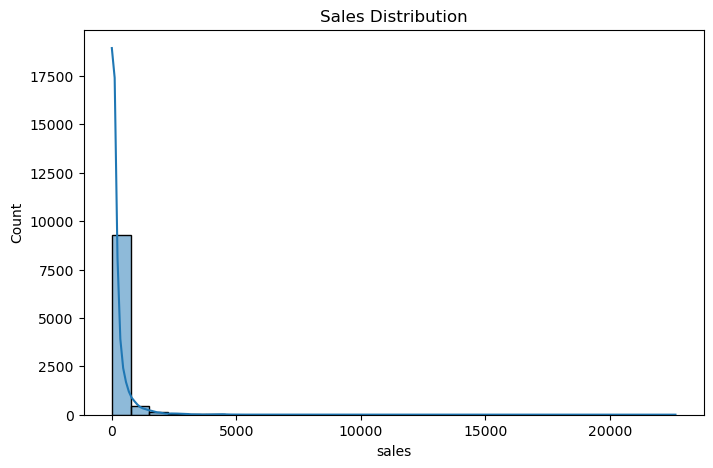

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["sales"], bins=30, kde=True)
plt.title("Sales Distribution")
plt.show()

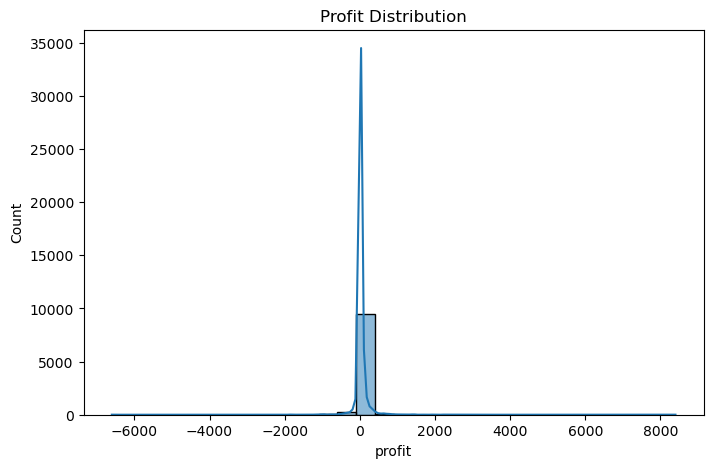

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df["profit"], bins=30, kde=True)
plt.title("Profit Distribution")
plt.show()

In [10]:
west_profit = df[df["region"] == "West"]["profit"]
east_profit = df[df["region"] == "East"]["profit"]

t_stat, p_value = stats.ttest_ind(west_profit, east_profit)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 0.31911690463165876
P-Value: 0.7496489079457462


In [11]:
contingency_table = pd.crosstab(df["region"], df["category"])

chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p)

Chi-Square Statistic: 3.8961901687654223
P-Value: 0.6907223540030415


In [12]:
confidence = 0.95

mean_sales = df["sales"].mean()
std_sales = df["sales"].std()

margin_error = stats.sem(df["sales"]) * stats.t.ppf(
    (1 + confidence) / 2,
    len(df["sales"]) - 1
)

lower = mean_sales - margin_error
upper = mean_sales + margin_error

print("95% Confidence Interval for Sales:")
print(lower, upper)

95% Confidence Interval for Sales:
217.90861872220412 242.38918428471172


In [13]:
summary = pd.DataFrame({
    "Metric": [
        "Mean Sales",
        "Median Sales",
        "Sales Std Dev",
        "Sales Skewness"
    ],
    "Value": [
        df["sales"].mean(),
        df["sales"].median(),
        df["sales"].std(),
        df["sales"].skew()
    ]
})

summary

,Metric,Value
0,Mean Sales,230.148902
1,Median Sales,54.816000
2,Sales Std Dev,623.721409
3,Sales Skewness,12.963770


In [14]:
features = df[["sales", "quantity", "discount", "profit"]]

features.head()

,sales,quantity,discount,profit
0,261.9600,2,0.00,41.9136
1,731.9400,3,0.00,219.5820
2,14.6200,2,0.00,6.8714
3,957.5775,5,0.45,-383.0310
4,22.3680,2,0.20,2.5164


In [15]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print("Scaled Data Shape:", scaled_features.shape)

Scaled Data Shape: (9977, 4)


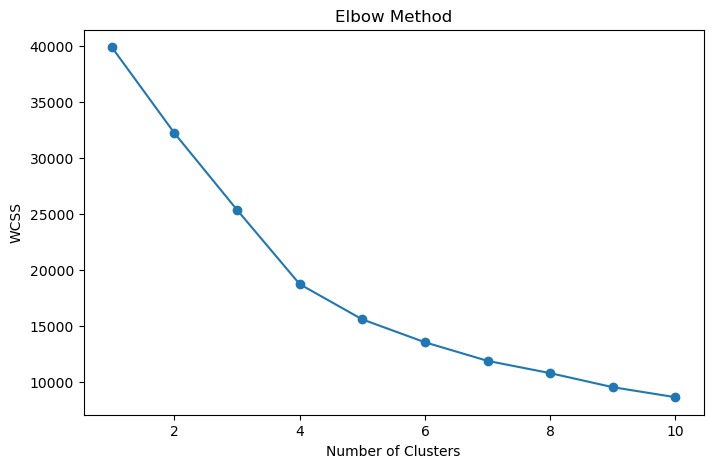

In [16]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(scaled_features)
    
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [17]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(scaled_features)

df[["sales","profit","Cluster"]].head()

,sales,profit,Cluster
0,261.9600,41.9136,0
1,731.9400,219.5820,0
2,14.6200,6.8714,0
3,957.5775,-383.0310,3
4,22.3680,2.5164,0


In [18]:
df["Cluster"].value_counts()

Cluster
0    6069
1    2838
3    1043
2      27
Name: count, dtype: int64

In [19]:
pca = PCA(n_components=2)

pca_components = pca.fit_transform(scaled_features)

df["PCA1"] = pca_components[:, 0]
df["PCA2"] = pca_components[:, 1]

df[["PCA1", "PCA2", "Cluster"]].head()

,PCA1,PCA2,Cluster
0,0.042699,-1.051249,0
1,1.153771,-0.751365,0
2,-0.310407,-1.108566,0
3,-0.629225,1.962034,3
4,-0.576804,-0.406431,0


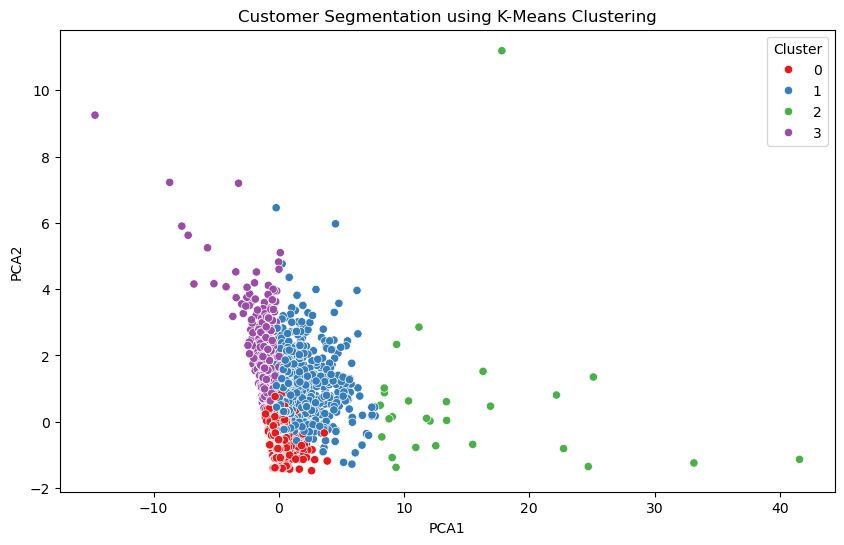

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1"
)

plt.title("Customer Segmentation using K-Means Clustering")
plt.show()

In [21]:
cluster_profile = df.groupby("Cluster")[
    ["sales", "quantity", "discount", "profit"]
].mean()

cluster_profile

,sales,quantity,discount,profit
Cluster,,,,
0,126.982857,2.531719,0.097563,21.546581
1,407.908020,6.452784,0.094655,69.790464
2,7685.179259,5.185185,0.070370,2610.220085
3,153.781235,3.837009,0.667833,-108.404658


In [22]:
df.to_csv(
    "../data/processed/superstore_with_clusters.csv",
    index=False
)

print("Clustered dataset saved successfully")

Clustered dataset saved successfully


In [23]:
X = df[["sales", "quantity", "discount"]]

y = df["profit"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (9977, 3)
y Shape: (9977,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (7981, 3)
Testing Data: (1996, 3)


In [25]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [26]:
y_pred = model.predict(X_test)

print("Predictions Generated")

Predictions Generated


In [27]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 59.80264225382047
RMSE: 250.8628369162763
R2 Score: 0.17412221963848074


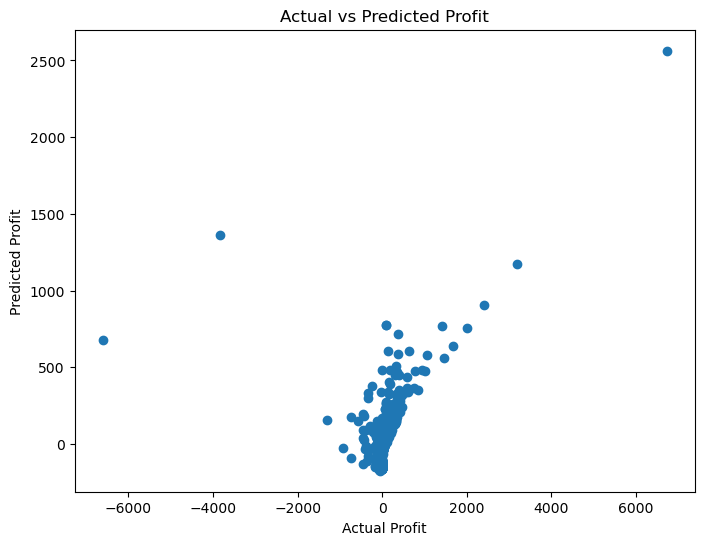

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")

plt.title("Actual vs Predicted Profit")

plt.show()

In [29]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,sales,0.181498
1,quantity,-3.071288
2,discount,-231.242863


In [30]:
df.to_csv(
    "../data/processed/final_task4_dataset.csv",
    index=False
)

print("Final dataset saved successfully")

Final dataset saved successfully


# Task 4 Conclusion

This project demonstrates advanced analytics techniques on the Superstore dataset.

Key activities completed:
- Statistical Analysis
- Data Distribution Analysis
- T-Test
- Chi-Square Test
- Confidence Interval Estimation
- Customer Segmentation using K-Means Clustering
- PCA-based Cluster Visualization
- Profit Prediction using Linear Regression

Model Evaluation:
- MAE: 59.80
- RMSE: 250.86
- R² Score: 0.1741

Tools Used:
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- SciPy